# **UTN Santa Fe - Ciencia de Datos**
## *TP N°1 - Parte 2: Preprocesamiento de datos y entrenamiento*

---
### **Librerías**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import classification_report, confusion_matrix, f1_score 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

---
### **Carga del conjunto de datos**
Realizamos la lectura del archivo `i40 (datos).csv` y visualizamos las primeras filas para comprobar que haya cargado correctamente.

In [2]:
# Leemos el archivo y visualizamos los primeros registros
df = pd.read_csv('i40 (datos).csv')
df.columns = df.columns.str.strip()
df.head()

,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
0,0,5291,L,303.80,313.30,1406,52.10,166,normal
1,1,3908,L,302.30,311.20,1633,36.40,114,normal
2,2,10767,M,302.27,311.47,1228,68.75,187,failure
3,3,15484,L,302.35,311.93,1522,36.99,214,failure
4,4,784,L,296.70,307.90,1743,27.90,55,normal


In [3]:
# Borramos los campos que no son necesarios para el modelo
df.drop('idx',axis=1, inplace=True)
df.drop('parent_device_id',axis=1, inplace=True)

df.head()

,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
0,L,303.80,313.30,1406,52.10,166,normal
1,L,302.30,311.20,1633,36.40,114,normal
2,M,302.27,311.47,1228,68.75,187,failure
3,L,302.35,311.93,1522,36.99,214,failure
4,L,296.70,307.90,1743,27.90,55,normal


---
## **Preprocesamiento de datos**

### **Detección y tratamiento de datos faltantes**

Verificamos si existen datos faltantes:

In [4]:
valores_faltantes = df.isnull().sum()
print(valores_faltantes[valores_faltantes > 0])

air_temp [K]    40
dtype: int64


Notamos que faltan 40 valores en la columna `air_temp [K]` y los rellenamos con la mediana:

In [5]:
mediana = df['air_temp [K]'].median()
df['air_temp [K]'] = df['air_temp [K]'].fillna(mediana)

valores_faltantes = df.isnull().sum()
print(valores_faltantes[valores_faltantes > 0])

Series([], dtype: int64)


---
### **Detección y tratamiento de valores atípicos**
Visualizamos los valores atípicos de las variables numéricas mediante boxplots:

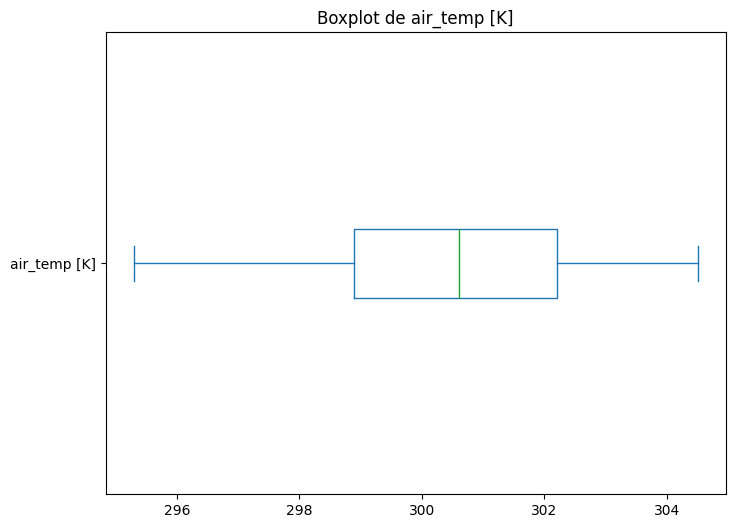

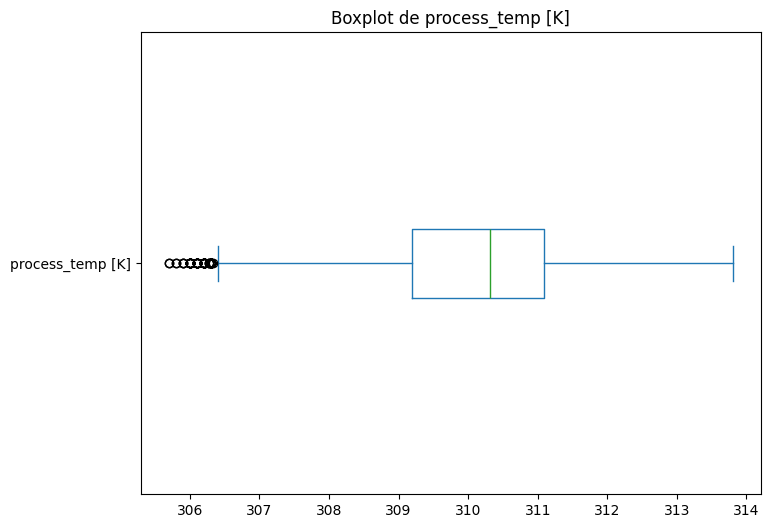

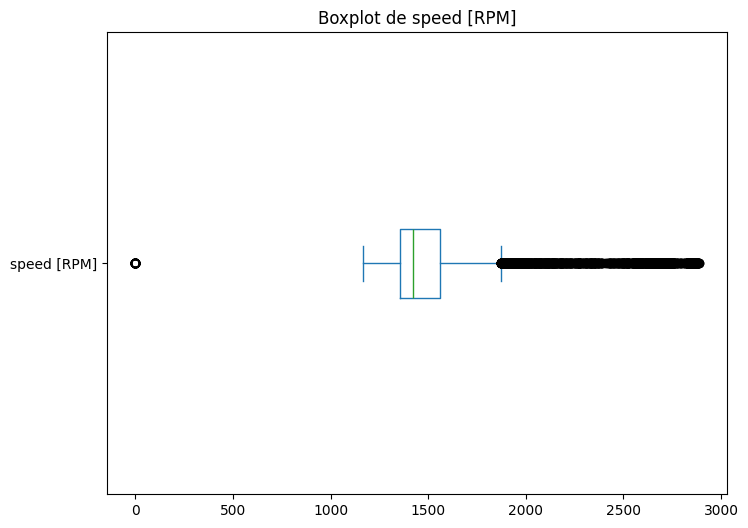

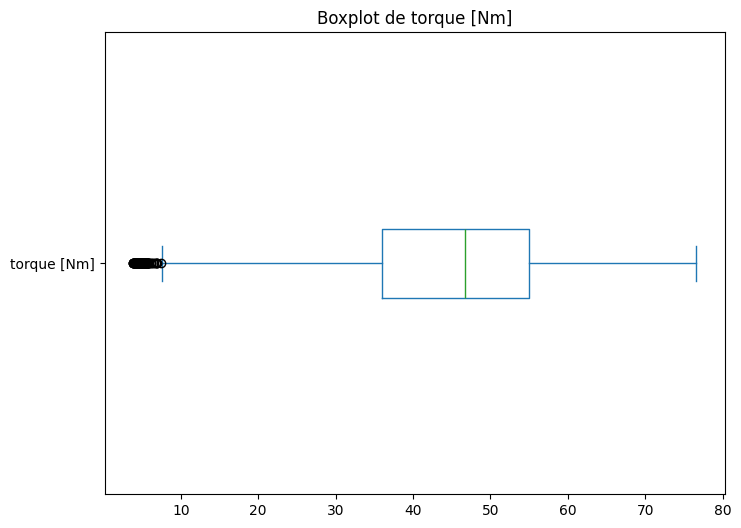

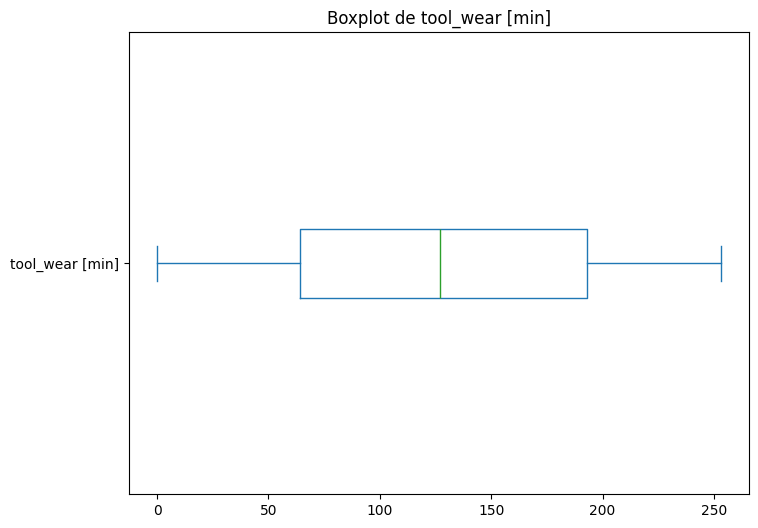

In [6]:
for columna in df.columns:
    if pd.api.types.is_numeric_dtype(df[columna]):
        plt.figure(figsize=(8, 6))
        df[columna].plot(kind='box', vert=False)
        plt.title(f"Boxplot de {columna}") 
        plt.show()

Notamos que las columnas de `process_temp [K]`, `speed [RPM]` y `torque [Nm]` presentan valores atípicos. Analizaremos la naturaleza de estos extremos antes de modificarlos. 

Comenzaremos buscando y corrigiendo mediante imputación únicamente los errores de sensor confirmados, como velocidades negativas o nulas. Basándonos en la física del problema, la variable `speed [RPM]` está relacionada con la variable `torque [Nm]`, por lo que utilizaremos esta información para deducir los valores más probables de `speed [RPM]`. Luego, cruzaremos los valores atípicos restantes con la variable objetivo (`target`) para evaluar si éstos representan eventos críticos vinculados a las fallas de la maquinaria.

-> Estos valores fueron imputados por vecinos cercanos, asumiendo error del sensor.

--- Análisis de outliers vs. target (eventos críticos) ---
Evaluamos si los valores extremos coinciden con las fallas de la maquinaria.

Variable: process_temp [K]
  - Cantidad de outliers: 67
  - Probabilidad falla rango normal: 51.72%
  - Probabilidad falla OUTLIERS:     8.96%
------------------------------------------------------------
Variable: speed [RPM]
  - Cantidad de outliers: 1145
  - Probabilidad falla rango normal: 49.99%
  - Probabilidad falla OUTLIERS:     69.52%
------------------------------------------------------------
Variable: torque [Nm]
  - Cantidad de outliers: 107
  - Probabilidad falla rango normal: 51.17%
  - Probabilidad falla OUTLIERS:     100.00%
------------------------------------------------------------


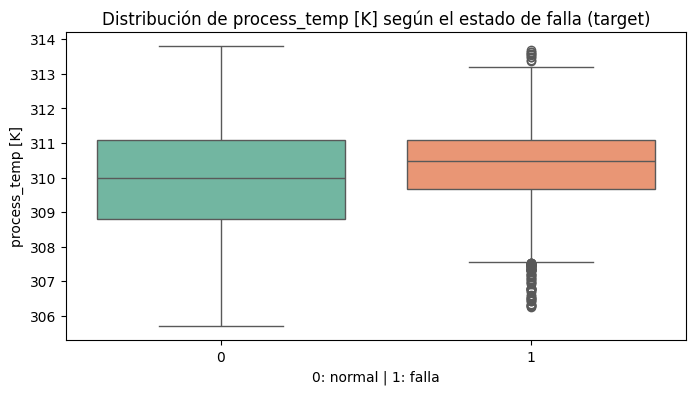

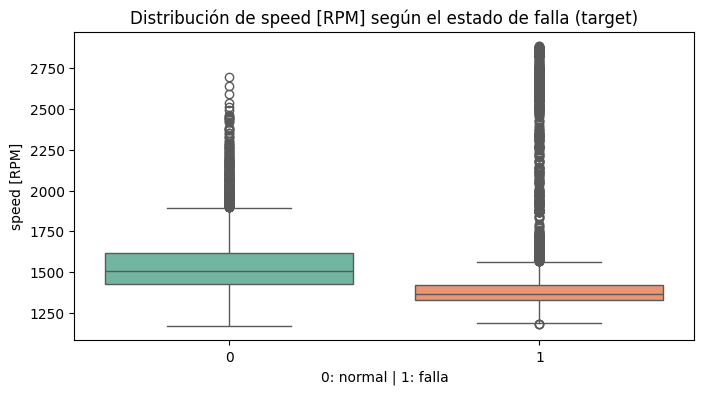

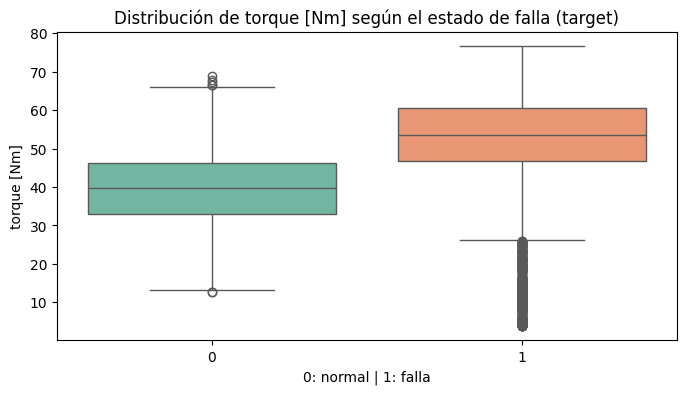

In [7]:
columnas = ['process_temp [K]', 'speed [RPM]', 'torque [Nm]']

# 1. Tratamiento de errores de sensor
# Identificamos los valores inválidos (0 o negativos) y los marcamos como nulos (NaN)
# Esto es necesario porque el KNNImputer solo llena valores que son NaN
df.loc[df['speed [RPM]'] <= 0, 'speed [RPM]'] = np.nan

# Buscamos los 5 registros con el torque más parecido
imputer = KNNImputer(n_neighbors=5)

# Aplicamos la imputación utilizando 'torque [Nm]' para predecir 'speed [RPM]'
df[['speed [RPM]', 'torque [Nm]']] = imputer.fit_transform(df[['speed [RPM]', 'torque [Nm]']])

print("-> Estos valores fueron imputados por vecinos cercanos, asumiendo error del sensor.")

# 2. Análisis de outliers como eventos críticos (fallas)
print("\n--- Análisis de outliers vs. target (eventos críticos) ---")
print("Evaluamos si los valores extremos coinciden con las fallas de la maquinaria.\n")

# Convertir target a valores binarios (0: normal, 1: falla)
if not pd.api.types.is_numeric_dtype(df['target']):
    df['target'] = df['target'].map({'normal': 0, 'failure': 1})

for col in columnas:
    # Calculamos límites estadísticos (IQR)
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    bajo = q1 - 1.5 * iqr
    alto = q3 + 1.5 * iqr
    
    # Identificamos qué filas son outliers estadísticos para esta columna
    es_outlier = (df[col] < bajo) | (df[col] > alto)
    cantidad_outliers = es_outlier.sum()
    
    if cantidad_outliers > 0:
        # Calculamos qué porcentaje de esos outliers resultaron en falla (target == 1)
        tasa_falla_normal = df.loc[~es_outlier, 'target'].mean() * 100
        tasa_falla_outlier = df.loc[es_outlier, 'target'].mean() * 100
        
        print(f"Variable: {col}")
        print(f"  - Cantidad de outliers: {cantidad_outliers}")
        print(f"  - Probabilidad falla rango normal: {tasa_falla_normal:.2f}%")
        print(f"  - Probabilidad falla OUTLIERS:     {tasa_falla_outlier:.2f}%")
        print("-" * 60)

# 3. Visualización
for col in columnas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='target', y=col, hue='target', palette='Set2', legend=False)
    plt.title(f"Distribución de {col} según el estado de falla (target)")
    plt.xlabel("0: normal | 1: falla")
    plt.show()

Decidimos no imputar los outliers restantes porque el análisis demostró que son señales predictivas fundamentales. Especialmente en el caso de `torque [Nm]`, detectamos que el 100% de los valores atípicos resultan en falla, lo que convierte a esta variable en un predictor absoluto en rangos extremos. Asimismo, las variaciones drásticas en la probabilidad de falla para `speed [RPM]` (sube al 69%) y `process_temp [K]` (baja al 9%) demuestran que eliminar estos datos destruiría los patrones más importantes que el modelo debe aprender.

---
### **Correlación entre variables**
Calculamos las correlaciones de las columnas numéricas según un umbral de 0.90:


No se encontraron variables para eliminar con el umbral establecido.


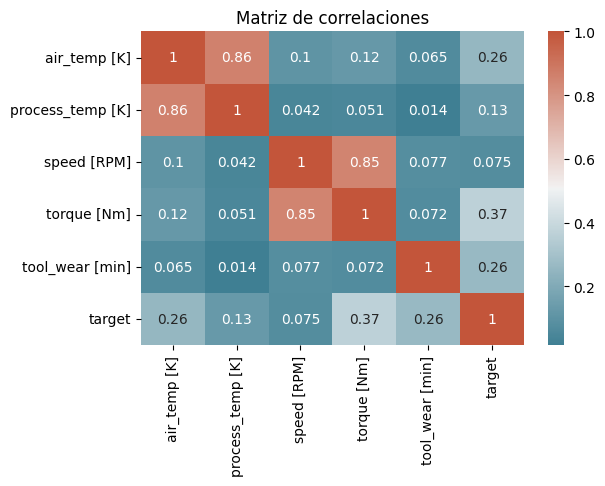

In [8]:
# Calculamos la matriz de correlación absoluta
corr = df.corr(numeric_only=True).abs()

# Calculamos un vector con las medias de cada columna
column_mean = corr.mean(axis=1)

# Visualizamos la matriz de correlación
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, cmap=sns.diverging_palette(220, 20, as_cmap=True))
plt.tight_layout()
plt.title("Matriz de correlaciones")

columnas_a_eliminar = set()

# Calculo de las correlaciones de las columnas dado el umbral
umbral = .90
df_numbers = df[['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']]

for i in range(0, len(df_numbers.columns)):
    for j in range(i, len(df_numbers.columns)):
        if i != j:
            col_i = df_numbers.columns[i]
            col_j = df_numbers.columns[j]
            is_corr = np.abs(df_numbers[col_i].corr(df_numbers[col_j]))
            
            if is_corr > umbral:
                print(f"La variable {col_i} está altamente correlacionada con {col_j}")
                
                # Se elimina la variable con mayor promedio de correlación
                if column_mean[col_i] > column_mean[col_j]:
                    columnas_a_eliminar.add(col_i)
                else:
                    columnas_a_eliminar.add(col_j)

# Eliminación de variables
if columnas_a_eliminar:
    print(f"\nEliminando columnas por alta redundancia: {columnas_a_eliminar}")
    df.drop(columns=list(columnas_a_eliminar), inplace=True)
else:
    print("\nNo se encontraron variables para eliminar con el umbral establecido.")

---
### **Procesamiento de variables categóricas**
En este caso sólo tenemos variables categóricas nominales (`product_type` y `target`). Para este tipo de variables categóricas se pretende evitar una ponderación que pueda sesgar el conjunto de datos, por lo que utilizaremos una codificación one-hot para la variable `product_type` pero no para la variable `target`, dado que la misma es binaria.

In [9]:
# Variable objetivo 'target': ya fue mapeada a valores binarios para el estudio y tratamiento de outliers
# 0: estado normal, 1: falla

# Variable nominal 'product_type': aplicamos codificación one-hot
df = pd.get_dummies(df, columns=['product_type'], dtype=int)

df.head()

,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target,product_type_H,product_type_L,product_type_M
0,303.80,313.30,1406.0,52.10,166,0,0,1,0
1,302.30,311.20,1633.0,36.40,114,0,0,1,0
2,302.27,311.47,1228.0,68.75,187,1,0,0,1
3,302.35,311.93,1522.0,36.99,214,1,0,1,0
4,296.70,307.90,1743.0,27.90,55,0,0,1,0


---
### **Balance del conjunto de datos**
Para solucionar el desbalance del conjunto de datos utilizaremos la técnica de over-sampling, la cual se trata de aumentar la cantidad de muestras de la clase minoritaria para alcanzar a la más abundante. 

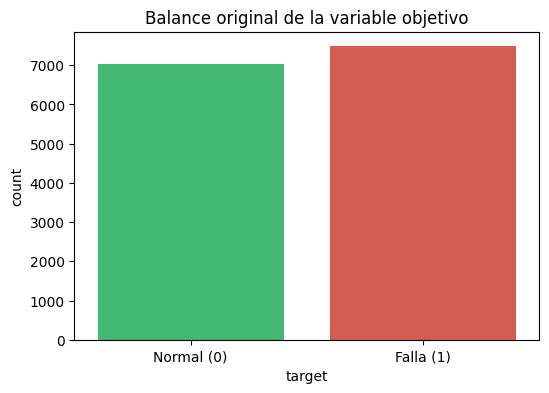

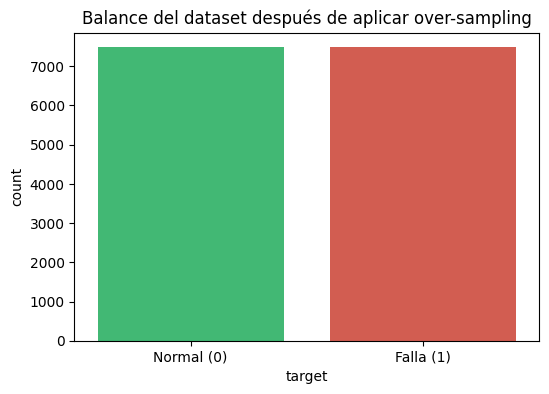

In [10]:
# Separamos el dataset en entradas (X) y salida esperada (y)
X = df.drop('target', axis=1)
y = df['target']

# Visualizamos el balance del dataset original
plt.figure(figsize=(6, 4))
sns.countplot(x=y, hue=y, palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title("Balance original de la variable objetivo")
plt.xticks(ticks=[0, 1], labels=['Normal (0)', 'Falla (1)'])
plt.show()

# Generamos un nuevo conjunto de datos balanceado por over-sampling
oversample = RandomOverSampler(sampling_strategy='minority')

# Generamos el nuevo dataset balanceado
X_over, y_over = oversample.fit_resample(X, y)

# Visualización del balance del dataset generado
plt.figure(figsize=(6, 4))
sns.countplot(x=y_over, hue=y_over, palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title("Balance del dataset después de aplicar over-sampling")
plt.xticks(ticks=[0, 1], labels=['Normal (0)', 'Falla (1)'])
plt.show()

---
### **Normalización del conjunto de datos**
Normalizaremos para igualar la escala de todas las variables, evitando que aquellas con números más grandes (como las revoluciones) dominen injustamente el aprendizaje del modelo sobre las más pequeñas (como la temperatura) y permitiendo que el algoritmo aprenda con mayor rapidez y precisión.

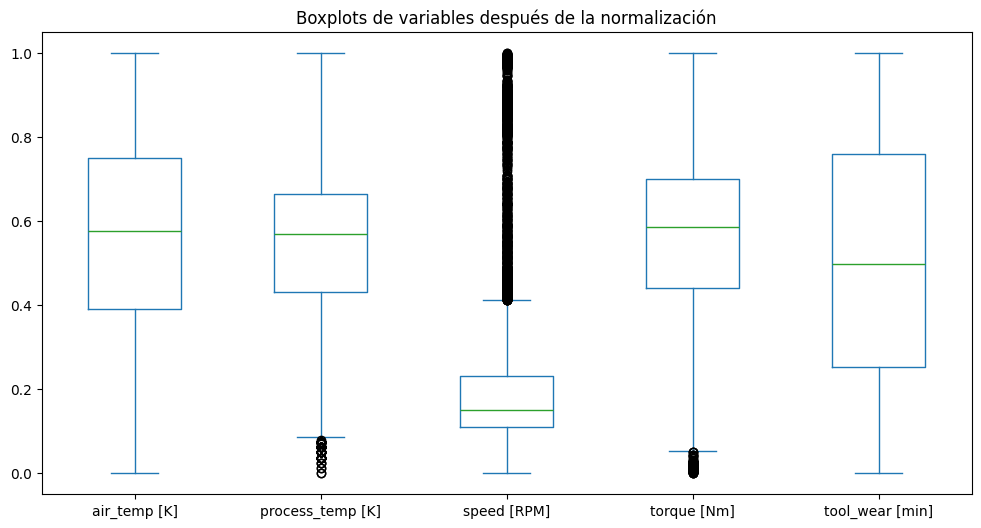

In [11]:
# Copiar las variables ya balanceadas
X_normal = X_over.copy()
  
# Aplicamos normalización manual a las columnas numéricas (excluimos las categóricas codificadas)
columns = ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']

# Escalado Min-Max
for column in columns:
    min_val = X_normal[column].min()
    max_val = X_normal[column].max()
    
    X_normal[column] = (X_normal[column] - min_val) / (max_val - min_val)  

# Visualizamos la distribución de las distintas variables normalizadas
fig, ax = plt.subplots(figsize=(12, 6))
X_normal.loc[:, columns].plot(kind='box', ax=ax)
plt.title("Boxplots de variables después de la normalización")
plt.show()

---
## **Entrenamiento**

Comenzaremos separando el conjunto balanceado y normalizado en 70% entrenamiento y 30% test.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_normal, y_over, test_size=0.3, random_state=42)

### **Regresión logística**
Procederemos a entrenar nuestro algoritmo predictivo. Para maximizar su rendimiento y evitar el sobreajuste, implementaremos una búsqueda iterativa para ajustar el hiperparámetro de regularización (`C`). Evaluaremos distintos escenarios y seleccionaremos el mejor modelo basándonos en su `F1-Score`.

Finalmente, validaremos la capacidad real del modelo para operar en la fábrica analizando su matriz de confusión y su reporte de clasificación, prestando especial atención a minimizar los falsos negativos (fallas reales que el modelo no logra detectar).

Buscando el mejor valor de C (regularización)...

C = 0.01 -> F1-Score: 0.7679
C = 0.1 -> F1-Score: 0.8257
C = 1 -> F1-Score: 0.8475
C = 10 -> F1-Score: 0.8485
C = 100 -> F1-Score: 0.8489

Mejor hiperparámetro encontrado: C = 100


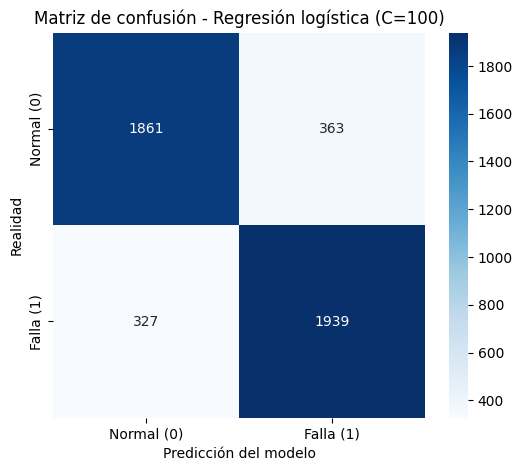


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      2224
           1       0.84      0.86      0.85      2266

    accuracy                           0.85      4490
   macro avg       0.85      0.85      0.85      4490
weighted avg       0.85      0.85      0.85      4490



In [14]:
# 1. Ajuste de hiperparámetros (parámetro C)
print("Buscando el mejor valor de C (regularización)...\n")

valores_C = [0.01, 0.1, 1, 10, 100]
mejor_f1 = 0
mejor_C = 0

for c in valores_C:
    # Instanciar y entrenar el modelo con el C actual
    modelo_tmp = LogisticRegression(C=c, max_iter=2000)
    modelo_tmp.fit(X_train, y_train)
    
    # Evaluar la precisión con F1-Score sobre el conjunto de test
    y_pred_tmp = modelo_tmp.predict(X_test)
    f1 = f1_score(y_test, y_pred_tmp)
    
    print(f"C = {c} -> F1-Score: {f1:.4f}")
    
    if f1 > mejor_f1:
        mejor_f1 = f1
        mejor_C = c

print(f"\nMejor hiperparámetro encontrado: C = {mejor_C}")

# 2. Entrenamiento definitivo
model_LR = LogisticRegression(C=mejor_C, max_iter=2000)
model_LR.fit(X_train, y_train)

# 3. Evaluación del modelo final
y_pred = model_LR.predict(X_test)

# Matriz de confusión 
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (0)', 'Falla (1)'], 
            yticklabels=['Normal (0)', 'Falla (1)'])
plt.title(f'Matriz de confusión - Regresión logística (C={mejor_C})')
plt.xlabel('Predicción del modelo')
plt.ylabel('Realidad')
plt.show()

# Reporte de clasificación 
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

---
### **Árbol de decisión**
Como segundo enfoque, implementaremos un modelo de árbol de decisión. A diferencia de la regresión logística (que es paramétrica y lineal), el árbol de decisión utiliza un enfoque basado en reglas que nos permite capturar relaciones no lineales entre las variables físicas de la máquina.

Para evitar el sobreajuste (que el árbol memorice los datos y crezca demasiado), realizaremos una búsqueda del mejor hiperparámetro de profundidad máxima (`max_depth`). Optimizaremos este valor buscando el mayor `F1-Score` y evaluaremos el modelo final con su respectiva matriz de confusión.

Buscando la mejor profundidad máxima (max_depth) para el árbol...

max_depth = 3 -> F1-Score: 0.8849
max_depth = 5 -> F1-Score: 0.9372
max_depth = 7 -> F1-Score: 0.9423
max_depth = 10 -> F1-Score: 0.9546
max_depth = 15 -> F1-Score: 0.9568

Mejor hiperparámetro encontrado: max_depth = 15


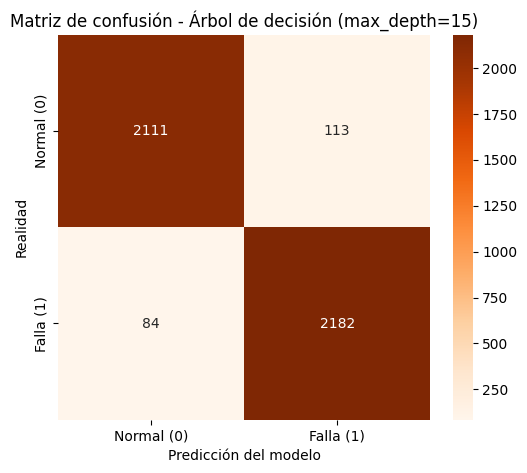


Reporte de clasificación
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      2224
           1       0.95      0.96      0.96      2266

    accuracy                           0.96      4490
   macro avg       0.96      0.96      0.96      4490
weighted avg       0.96      0.96      0.96      4490



In [15]:
# 1. Búsqueda del hiperparámetro 'max_depth'
print("Buscando la mejor profundidad máxima (max_depth) para el árbol...\n")

# Probamos distintas profundidades para ver cuál generaliza mejor
valores_profundidad = [3, 5, 7, 10, 15]
mejor_f1_tree = 0
mejor_prof_tree = 0

for prof in valores_profundidad:
    # Instanciamos el modelo con la profundidad actual
    modelo_tree_tmp = DecisionTreeClassifier(max_depth=prof, random_state=42)
    modelo_tree_tmp.fit(X_train, y_train)
    
    # Predecimos y evaluamos usando el conjunto de test
    y_pred_tmp = modelo_tree_tmp.predict(X_test)
    f1_tree = f1_score(y_test, y_pred_tmp)
    
    print(f"max_depth = {prof} -> F1-Score: {f1_tree:.4f}")
    
    # Guardamos el mejor resultado
    if f1_tree > mejor_f1_tree:
        mejor_f1_tree = f1_tree
        mejor_prof_tree = prof

print(f"\nMejor hiperparámetro encontrado: max_depth = {mejor_prof_tree}")

# 2. Entrenamiento final y evaluación
# Entrenamos el modelo definitivo con la profundidad ganadora
modelo_tree_final = DecisionTreeClassifier(max_depth=mejor_prof_tree, random_state=42)
modelo_tree_final.fit(X_train, y_train)

# Predicción final sobre los datos de prueba
y_pred_tree = modelo_tree_final.predict(X_test)

# Matriz de confusión
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal (0)', 'Falla (1)'], 
            yticklabels=['Normal (0)', 'Falla (1)'])
plt.title(f'Matriz de confusión - Árbol de decisión (max_depth={mejor_prof_tree})')
plt.xlabel('Predicción del modelo')
plt.ylabel('Realidad')
plt.show()

# Reporte de clasificación
print("\nReporte de clasificación")
print(classification_report(y_test, y_pred_tree))

---
### **Random Forest**
Para complementar nuestro análisis, entrenaremos un modelo de ensamble basado en bosques aleatorios. Este modelo puede capturar relaciones no lineales y patrones más complejos en las variables físicas de la máquina mediante la creación de múltiples árboles de decisión.

Realizaremos una búsqueda iterativa para optimizar el hiperparámetro de profundidad máxima (`max_depth`) de los árboles, buscando el modelo que maximice nuestro `F1-Score` para la detección de fallas, y posteriormente lo evaluaremos con nuestra matriz de confusión.

Buscando la mejor profundidad máxima (max_depth) para Random Forest...

max_depth = 3 -> F1-Score: 0.8925
max_depth = 5 -> F1-Score: 0.9279
max_depth = 10 -> F1-Score: 0.9552
max_depth = 20 -> F1-Score: 0.9676

Mejor hiperparámetro encontrado: max_depth = 20


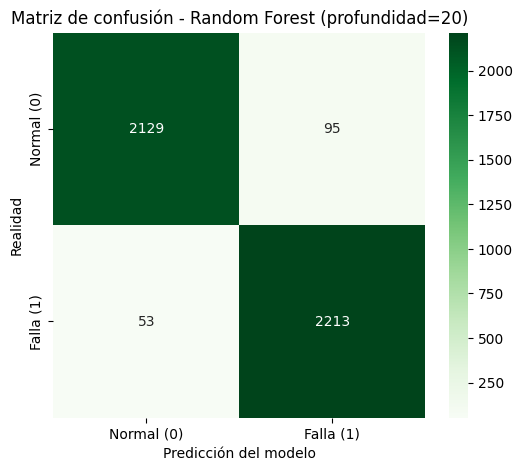


Reporte de clasificación
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      2224
           1       0.96      0.98      0.97      2266

    accuracy                           0.97      4490
   macro avg       0.97      0.97      0.97      4490
weighted avg       0.97      0.97      0.97      4490



In [16]:
from sklearn.ensemble import RandomForestClassifier

# 1. Búsqueda del hiperparámetro 'max_depth'
print("Buscando la mejor profundidad máxima (max_depth) para Random Forest...\n")

# Probamos distintas profundidades para los árboles 
valores_profundidad = [3, 5, 10, 20]
mejor_f1_rf = 0
mejor_profundidad = 0

for prof in valores_profundidad:
    # Instanciamos el modelo con 100 árboles (n_estimators=100)
    modelo_rf_tmp = RandomForestClassifier(n_estimators=100, max_depth=prof, random_state=42)
    modelo_rf_tmp.fit(X_train, y_train)
    
    # Predecimos y evaluamos usando el conjunto de test
    y_pred_tmp = modelo_rf_tmp.predict(X_test)
    f1_rf = f1_score(y_test, y_pred_tmp)
    
    print(f"max_depth = {prof} -> F1-Score: {f1_rf:.4f}")
    
    # Guardamos el mejor resultado
    if f1_rf > mejor_f1_rf:
        mejor_f1_rf = f1_rf
        mejor_profundidad = prof

print(f"\nMejor hiperparámetro encontrado: max_depth = {mejor_profundidad}")

# 2. Entrenamiento final y evaluación
# Entrenamos el modelo definitivo
modelo_rf_final = RandomForestClassifier(n_estimators=100, max_depth=mejor_profundidad, random_state=42)
modelo_rf_final.fit(X_train, y_train)

# Predicción final
y_pred_rf = modelo_rf_final.predict(X_test)

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', # Lo pongo en verde para diferenciarlo del anterior
            xticklabels=['Normal (0)', 'Falla (1)'], 
            yticklabels=['Normal (0)', 'Falla (1)'])
plt.title(f'Matriz de confusión - Random Forest (profundidad={mejor_profundidad})')
plt.xlabel('Predicción del modelo')
plt.ylabel('Realidad')
plt.show()

# Reporte de clasificación
print("\nReporte de clasificación")
print(classification_report(y_test, y_pred_rf))

---
### **Comparación de los modelos**

Para concluir el análisis, realizaremos una comparación directa entre los tres enfoques utilizados.

A continuación, generaremos una tabla resumen y un gráfico de barras que contrastan las métricas principales. Nuestro enfoque principal para determinar el mejor modelo será el `F1-Score` y el `recall` de la clase crítica (`"falla"`), ya que en el contexto industrial minimizar los falsos negativos es la máxima prioridad.

--- TABLA COMPARATIVA DE RENDIMIENTO ---
                Modelo  Accuracy (general)  Precision (fallas)  \
0  Regresión logística              0.8463              0.8423   
1    Árbol de decisión              0.9561              0.9508   
2        Random Forest              0.9670              0.9588   

   Recall (fallas)  F1-Score (fallas)  
0           0.8557             0.8489  
1           0.9629             0.9568  
2           0.9766             0.9676  


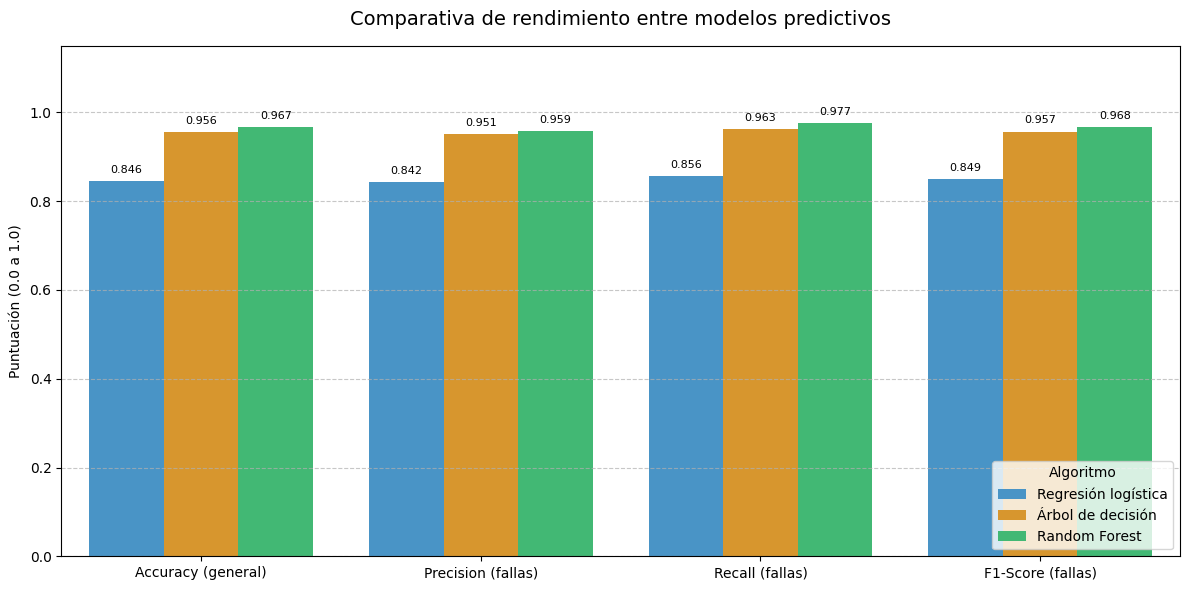

In [17]:
# 1. Cálculo automático de las métricas para cada modelo

# Métricas para regresión logística
acc_lr = accuracy_score(y_test, y_pred)
prec_lr = precision_score(y_test, y_pred)
rec_lr = recall_score(y_test, y_pred)
f1_lr = f1_score(y_test, y_pred)

# Métricas para árbol de decisión
acc_tree = accuracy_score(y_test, y_pred_tree)
prec_tree = precision_score(y_test, y_pred_tree)
rec_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

# Métricas para Random Forest
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# 2. Tabla comparativa
data_comparativa = {
    'Modelo': ['Regresión logística', 'Árbol de decisión', 'Random Forest'],
    'Accuracy (general)': [acc_lr, acc_tree, acc_rf],
    'Precision (fallas)': [prec_lr, prec_tree, prec_rf],
    'Recall (fallas)': [rec_lr, rec_tree, rec_rf],
    'F1-Score (fallas)': [f1_lr, f1_tree, f1_rf]
}

df_comparativa = pd.DataFrame(data_comparativa)

print("--- TABLA COMPARATIVA DE RENDIMIENTO ---")
print(df_comparativa.round(4))

# 3. Visualización mediante gráfico de barras
# Transformamos el DataFrame al formato ideal para Seaborn
df_melted = df_comparativa.melt(id_vars='Modelo', var_name='Métrica', value_name='Puntaje')

plt.figure(figsize=(12, 6)) 
colores = ['#3498db', '#f39c12', '#2ecc71']
sns.barplot(data=df_melted, x='Métrica', y='Puntaje', hue='Modelo', palette=colores)

plt.title('Comparativa de rendimiento entre modelos predictivos', fontsize=14, pad=15)
plt.ylabel('Puntuación (0.0 a 1.0)')
plt.xlabel('')
plt.ylim(0, 1.15) 
plt.legend(loc='lower right', title='Algoritmo')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f"{p.get_height():.3f}", 
                           (p.get_x() + p.get_width() / 2., p.get_height()), 
                           ha='center', va='center', xytext=(0, 8), 
                           textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()

---
### **Exportación del archivo procesado**

Exportaremos los conjuntos de entrenamiento y validación generados para utilizarlos en el entrenamiento y evaluación de una red neuronal MLP (en la materia Inteligencia Artificial).

In [20]:
# Para X
pd.DataFrame(X_train).to_csv('X_train.csv', index=False)
pd.DataFrame(X_test).to_csv('X_test.csv', index=False)

# para y
pd.DataFrame(y_train).to_csv('y_train.csv', index=False)
pd.DataFrame(y_test).to_csv('y_test.csv', index=False)

print("¡Datos exportados a CSV con éxito!")

¡Datos exportados a CSV con éxito!
